--- Task 1: First Few Records ---
   House_Size  House_Price
0         600           25
1         800           32
2        1000           38
3        1200           45
4        1400           52 



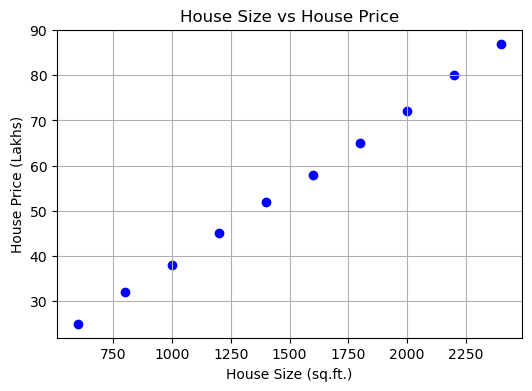

Comment (Task 2): There is a strong, positive linear relationship between house size and house price.

--- Task 5: Model Parameters ---
Regression Constant (Intercept, θ0): 3.9138
Regression Coefficient (Slope, θ1): 0.0342

--- Task 6: Test Set Comparison ---
   Actual  Predicted
0      80  79.206897
1      32  31.293103 

--- Task 7: Predictions for Specific Sizes ---
Size: 1500 sq.ft. -> Predicted Price: 55.25 Lakhs
Size: 1700 sq.ft. -> Predicted Price: 62.09 Lakhs
Size: 2500 sq.ft. -> Predicted Price: 89.47 Lakhs



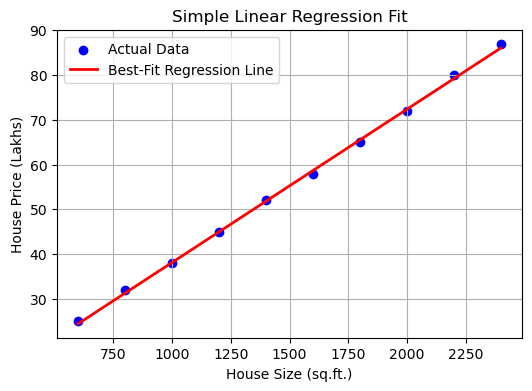

Comment (Task 8): The regression line closely passes through or near all data points, confirming a strong fit.

--- Task 9: Evaluation Metrics ---
Mean Absolute Error (MAE): 0.4879
Mean Squared Error (MSE): 0.3232
Root Mean Squared Error (RMSE): 0.5685
R2 Score: 0.9992



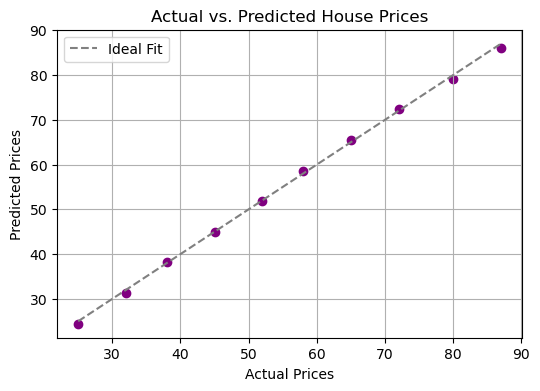

Comment (Task 10): The points lie very close to the ideal dashed diagonal line, indicating high prediction accuracy of the model.


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# --- Task 1: Create the dataset ---
data = {
    "House_Size": [600, 800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400],
    "House_Price": [25, 32, 38, 45, 52, 58, 65, 72, 80, 87],
}
df = pd.DataFrame(data)
print("--- Task 1: First Few Records ---")
print(df.head(), "\n")

# --- Task 2: Exploratory Data Visualization ---
plt.figure(figsize=(6, 4))
plt.scatter(df["House_Size"], df["House_Price"], color="blue")
plt.title("House Size vs House Price")
plt.xlabel("House Size (sq.ft.)")
plt.ylabel("House Price (Lakhs)")
plt.grid(True)
plt.show()
print(
    "Comment (Task 2): There is a strong, positive linear relationship between house size and house price.\n"
)

# --- Task 3: Split into training and testing sets (80:20 ratio) ---
X = df[["House_Size"]]
y = df["House_Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Task 4: Build Simple Linear Regression model ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- Task 5: Display model parameters ---
print("--- Task 5: Model Parameters ---")
print(f"Regression Constant (Intercept, θ0): {model.intercept_:.4f}")
print(f"Regression Coefficient (Slope, θ1): {model.coef_[0]:.4f}\n")

# --- Task 6: Predict on test dataset and compare ---
y_pred_test = model.predict(X_test)
comparison_df = pd.DataFrame(
    {"Actual": y_test, "Predicted": y_pred_test}
).reset_index(drop=True)
print("--- Task 6: Test Set Comparison ---")
print(comparison_df, "\n")

# --- Task 7: Predict for specific house sizes ---
new_sizes = pd.DataFrame({"House_Size": [1500, 1700, 2500]})
new_predictions = model.predict(new_sizes)
print("--- Task 7: Predictions for Specific Sizes ---")
for size, price in zip(new_sizes["House_Size"], new_predictions):
    print(f"Size: {size} sq.ft. -> Predicted Price: {price:.2f} Lakhs")
print()

# --- Task 8: Plot regression line with original data ---
plt.figure(figsize=(6, 4))
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(
    X,
    model.predict(X),
    color="red",
    linewidth=2,
    label="Best-Fit Regression Line",
)
plt.title("Simple Linear Regression Fit")
plt.xlabel("House Size (sq.ft.)")
plt.ylabel("House Price (Lakhs)")
plt.legend()
plt.grid(True)
plt.show()
print(
    "Comment (Task 8): The regression line closely passes through or near all data points, confirming a strong fit.\n"
)

# --- Task 9: Evaluate performance metrics ---
y_pred_all = model.predict(X)
mae = mean_absolute_error(y, y_pred_all)
mse = mean_squared_error(y, y_pred_all)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred_all)

print("--- Task 9: Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score: {r2:.4f}\n")

# --- Task 10: Plot Actual vs Predicted values ---
plt.figure(figsize=(6, 4))
plt.scatter(y, y_pred_all, color="purple")
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    color="gray",
    linestyle="--",
    label="Ideal Fit",
)
plt.title("Actual vs. Predicted House Prices")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.legend()
plt.grid(True)
plt.show()
print(
    "Comment (Task 10): The points lie very close to the ideal dashed diagonal line, indicating high prediction accuracy of the model."
)